In [1]:
import kagglehub
import pandas as pd
import numpy as np
import os


try:
    path = kagglehub.dataset_download("chethuhn/network-intrusion-dataset")
    data = pd.read_csv(os.path.join(path, 'Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv' ))
    print('Thursday data confirmed. :)')

except Exception as e:
    print(f'Something went wrong {e}')


data.head()

Thursday data confirmed. :)


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,389,113095465,48,24,9668,10012,403,0,201.416667,203.548293,...,32,203985.500,5.758373e+05,1629110,379,13800000.0,4.277541e+06,16500000,6737603,BENIGN
1,389,113473706,68,40,11364,12718,403,0,167.117647,171.919413,...,32,178326.875,5.034269e+05,1424245,325,13800000.0,4.229413e+06,16500000,6945512,BENIGN
2,0,119945515,150,0,0,0,0,0,0.000000,0.000000,...,0,6909777.333,1.170000e+07,20400000,6,24400000.0,2.430000e+07,60100000,5702188,BENIGN
3,443,60261928,9,7,2330,4221,1093,0,258.888889,409.702161,...,20,0.000,0.000000e+00,0,0,0.0,0.000000e+00,0,0,BENIGN
4,53,269,2,2,102,322,51,51,51.000000,0.000000,...,32,0.000,0.000000e+00,0,0,0.0,0.000000e+00,0,0,BENIGN


In [2]:
from sklearn.preprocessing import LabelEncoder

data.columns = data.columns.str.strip()

le = LabelEncoder()


data['Label'] = le.fit_transform(data['Label'])

data.replace([np.inf, -np.inf], np.nan, inplace=True)
data.dropna(inplace=True)

X = data.drop('Label', axis=1)
y = data['Label']

In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, test_size=0.2, random_state=1)

In [4]:
from  xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)

for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), 1):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx] 

    xgb = XGBClassifier(eval_metric='mlogloss', random_state=1)
    xgb.fit(X_train, y_train)


    y_pred = xgb.predict(X_test)
    print('-Fold--')
    print(classification_report(y_test, y_pred))

-Fold--
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     33611
           1       0.73      0.84      0.78       301
           2       1.00      0.80      0.89         5
           3       0.45      0.29      0.35       130

    accuracy                           1.00     34047
   macro avg       0.80      0.73      0.76     34047
weighted avg       1.00      1.00      1.00     34047

-Fold--
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     33610
           1       0.76      0.84      0.80       302
           2       0.80      1.00      0.89         4
           3       0.50      0.35      0.41       130

    accuracy                           1.00     34046
   macro avg       0.76      0.80      0.78     34046
weighted avg       1.00      1.00      1.00     34046

-Fold--
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     336

4
1.0
[0.02292823 0.00711016 0.03777729 0.02184994 0.01275693 0.04472708
 0.01444851 0.         0.03011448 0.00888299 0.00199424 0.
 0.00458015 0.00354757 0.06208004 0.00424119 0.00269807 0.00296046
 0.00777523 0.00419586 0.00325252 0.00280536 0.00666083 0.00446796
 0.03999847 0.01172092 0.03030109 0.00309741 0.00220759 0.01171315
 0.         0.         0.         0.         0.01886229 0.03879192
 0.00365484 0.01225815 0.         0.03821119 0.00678355 0.00266015
 0.         0.         0.         0.         0.         0.
 0.00720511 0.         0.         0.00043943 0.00709374 0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.01075072 0.3757777  0.0528747  0.01254433 0.         0.
 0.         0.         0.         0.00119851 0.         0.        ]
Init_Win_bytes_backward        0.375778
Flow Bytes/s                   0.062080
act_data_pkt_fwd               0.052875
Total Length of Bwd Packets    0.044727
Fwd IAT Mi

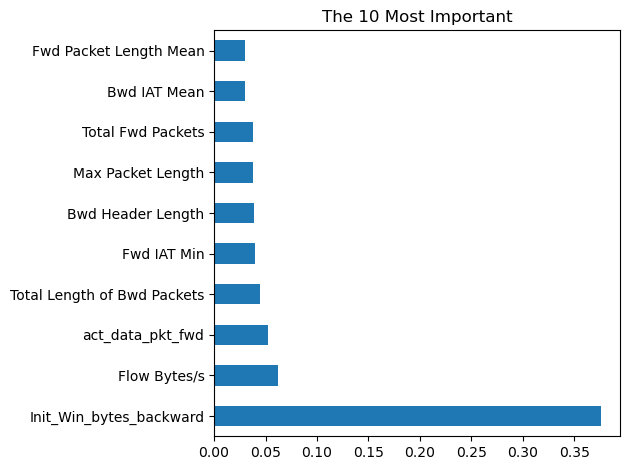

In [5]:
import matplotlib.pyplot as plt

xgb_importance = XGBClassifier(eval_metric='mlogloss', random_state=1)
xgb_importance.fit(X,y)


print(xgb_importance.n_classes_)
print(xgb_importance.feature_importances_.sum())
print(xgb_importance.feature_importances_)

importance = pd.Series(xgb_importance.feature_importances_, index=X.columns)
print(importance.nlargest(10))

importance.nlargest(10).plot(kind='barh')
plt.title('Top 10 Features - XGBoost')
plt.tight_layout()
plt.show()